# RQ2 — Do Algorithmic Communities Recover the Tactical Lines?

**Project: Passing Networks — 2022 World Cup Semi-finalists**  
*Module Network Science — Analisi e Visualizzazione delle Reti Complesse*

---

## Objective of RQ2

The goal is to test whether community detection algorithms (Louvain, Leiden, Infomap) automatically recover the tactical partition of players into four lines: **GK / DEF / MID / ATT**.

To do so we:
1. Build the **ground truths** from StatsBomb data
2. Run the **three algorithms** on the passing networks
3. **Evaluate** the agreement between algorithmic partitions and ground truths via NMI, AMI and F1
4. Test **alternative ground truths** (SIDE, ROLE_SIDE, TENURE) to identify what the algorithms actually capture

---
> **Notebook structure:**  
> - §0 Installation & imports  
> - §1 Loading shared data  
> - §2 Building ground truths  
> - §3 Community detection (Louvain, Leiden, Infomap)  
> - §4 Evaluation: NMI, AMI, F1  
> - §5 Alternative ground truths  
> - §6 Consolidated results and visualisations  
> - §7 Interpretation and conclusion

## §0 — Installation and imports

Community detection libraries are not part of the standard Colab environment.  
We install them here. `python-louvain` provides the Louvain algorithm via the `community` module.  
`leidenalg` + `igraph` for Leiden. `infomap` for Infomap (natively supports directed graphs).

In [1]:
# Libraries already installed in the environment; installation cell disabled for re-execution.
# !pip install -qq statsbombpy python-louvain leidenalg igraph infomap
print('deps OK')


deps OK


In [2]:
# Standard imports
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from collections import defaultdict
from itertools import combinations

# Community detection
from community import community_louvain        # Louvain (python-louvain)
import leidenalg                               # Leiden
import igraph as ig                            # backend for Leiden
import infomap                                 # Infomap (natively supports directed graphs)

# Evaluation
from sklearn.metrics import (
    normalized_mutual_info_score,
    adjusted_mutual_info_score,
    f1_score
)

# StatsBomb
from statsbombpy import sb

warnings.filterwarnings('ignore')

TEAMS = ['Argentina', 'France', 'Croatia', 'Morocco']
print("✓ Imports OK")

✓ Imports OK


## §1 — Loading shared data

We load the networks of the four semi-finalists. If the shared `.pkl` files are present in `shared_data/`, we read them; otherwise the notebook **rebuilds** the networks directly from StatsBomb using the same pipeline as RQ1/RQ3 (30-minute inclusion threshold), ensuring identical networks across all three notebooks. Each node carries `avg_x` / `avg_y` attributes (mean position on the pitch, StatsBomb 120×80 m frame).


In [3]:
# ---------------------------------------------------------------------------
# Loading shared networks.
#
# The notebook first tries to read the shared .pkl files if they exist
# (DATA_DIR). Otherwise it REBUILDS all four networks directly from
# StatsBomb using exactly the same pipeline as RQ1/RQ3 (30-minute threshold),
# so networks are identical across all three notebooks and RQ2
# works on any machine without depending on external files.
# Nodes carry avg_x / avg_y attributes (mean position).
# ---------------------------------------------------------------------------
import os

DATA_DIR     = "sample_data/shared_data/"
CACHE_PATH   = "wc2022_graphs_rq2.pkl"          # local RQ2 cache
COMPETITION_ID, SEASON_ID = 43, 106
MIN_MINUTES  = 30

def _classify_line(position_name):
    if not isinstance(position_name, str):
        return "MID"
    p = position_name.lower()
    if "goalkeeper" in p:                       return "GK"
    if "back" in p:                             return "DEF"
    if "wing" in p and "wing back" not in p:    return "ATT"
    if "forward" in p or "striker" in p:        return "ATT"
    if "midfield" in p:                         return "MID"
    return "MID"

def _build_team_network(team_name, match_ids, min_minutes=MIN_MINUTES):
    """Aggregated passing network across the tournament — identical pipeline to RQ1/RQ3."""
    from statsbombpy import sb
    all_passes, mins, pos = [], {}, {}
    for mid in match_ids:
        ev = sb.events(match_id=mid)
        # minutes via Starting XI
        for _, row in ev[(ev["type"] == "Starting XI") & (ev["team"] == team_name)].iterrows():
            tac = row.get("tactics")
            if isinstance(tac, dict):
                for p in tac.get("lineup", []):
                    nm = p["player"]["name"]
                    mins[nm] = mins.get(nm, 0) + 90
                    pp = p.get("position", {})
                    if isinstance(pp, dict):
                        pos.setdefault(nm, pp.get("name", ""))
        # substitution corrections
        for _, row in ev[(ev["type"] == "Substitution") & (ev["team"] == team_name)].iterrows():
            passer, si = row.get("player"), row.get("substitution")
            if not isinstance(si, dict):
                continue
            off = passer["name"] if isinstance(passer, dict) else passer
            on  = si["replacement"]["name"]
            minute = row.get("minute", 90)
            mins[off] = mins.get(off, 0) - (90 - minute) if off in mins else minute
            mins[on]  = mins.get(on, 0) + (90 - minute)
        # completed passes
        ps = ev[(ev["type"] == "Pass") & (ev["team"] == team_name) & (ev["pass_outcome"].isna())].copy()
        ps["x_start"] = ps["location"].apply(lambda l: l[0] if isinstance(l, list) else np.nan)
        ps["y_start"] = ps["location"].apply(lambda l: l[1] if isinstance(l, list) else np.nan)
        all_passes.append(ps[["player", "pass_recipient", "x_start", "y_start"]]
                          .dropna(subset=["player", "pass_recipient"]))
    df = pd.concat(all_passes, ignore_index=True)
    eligible = {p for p, m in mins.items() if m >= min_minutes}
    df = df[df["player"].isin(eligible) & df["pass_recipient"].isin(eligible)]
    ec = df.groupby(["player", "pass_recipient"]).size().reset_index(name="weight")
    G = nx.DiGraph()
    for _, r in ec.iterrows():
        w = int(r["weight"])
        G.add_edge(r["player"], r["pass_recipient"], weight=w, distance=1.0 / w)
    avg = df.groupby("player").agg(x=("x_start", "mean"), y=("y_start", "mean")).reset_index()
    for _, r in avg.iterrows():
        if r["player"] in G.nodes():
            # avg_x / avg_y attributes expected by RQ2 (+ x/y and line for compat)
            G.nodes[r["player"]].update({
                "avg_x": r["x"], "avg_y": r["y"], "x": r["x"], "y": r["y"],
                "minutes": mins.get(r["player"], 0),
                "line": _classify_line(pos.get(r["player"], "")),
            })
    return G

def load_team_graphs():
    # 1) shared files present -> read them (team workflow)
    pkl = DATA_DIR + "team_graphs.pkl"
    if os.path.exists(pkl):
        with open(pkl, "rb") as f:
            g = pickle.load(f)
        # ensure avg_x/avg_y even if the pkl only carries x/y
        for G in g.values():
            for _, d in G.nodes(data=True):
                d.setdefault("avg_x", d.get("x", 60.0))
                d.setdefault("avg_y", d.get("y", 40.0))
print(f"✓ Networks loaded from {pkl}")
        return g
    # 2) local RQ2 cache
    if os.path.exists(CACHE_PATH):
        with open(CACHE_PATH, "rb") as f:
print(f"✓ Networks loaded from cache {CACHE_PATH}")
            return pickle.load(f)
    # 3) rebuild from StatsBomb (~1 min) — RQ1/RQ3 pipeline
print("Rebuilding networks from StatsBomb (~1 min, 30-min threshold)...")
    from statsbombpy import sb
    matches = sb.matches(competition_id=COMPETITION_ID, season_id=SEASON_ID)
    g = {}
    for team in TEAMS:
        tm = matches[(matches["home_team"] == team) | (matches["away_team"] == team)]
        g[team] = _build_team_network(team, tm["match_id"].tolist())
    with open(CACHE_PATH, "wb") as f:
        pickle.dump(g, f)
print(f"✓ Networks rebuilt and cached in {CACHE_PATH}")
    return g

team_graphs = load_team_graphs()

# Quick check
for team in TEAMS:
    G = team_graphs[team]
print(f"{team:10s} | {G.number_of_nodes():2d} nodes | {G.number_of_edges():3d} edges")


Reconstruction des réseaux depuis StatsBomb (~1 min, seuil 30 min)...
✓ Réseaux reconstruits et mis en cache dans wc2022_graphs_rq2.pkl
Argentina  | 18 nœuds | 260 arêtes
France     | 22 nœuds | 290 arêtes
Croatia    | 19 nœuds | 273 arêtes
Morocco    | 17 nœuds | 213 arêtes


## §2 — Building Ground Truths

### 2.1 Position → tactical line mapping (LINE)

StatsBomb provides detailed positions (e.g. `Left Center Back`, `Center Defensive Midfield`).  
We aggregate these into 4 tactical lines: **GK, DEF, MID, ATT**.

For each player present in the graph, we scan all their appearances across match lineups  
to identify their **dominant position** across the whole tournament.

In [4]:
# StatsBomb position → tactical line mapping
POSITION_TO_LINE = {
    'Goalkeeper':                    'GK',
    'Right Back':                    'DEF', 'Left Back':                   'DEF',
    'Center Back':                   'DEF', 'Right Center Back':           'DEF',
    'Left Center Back':              'DEF', 'Right Wing Back':             'DEF',
    'Left Wing Back':                'DEF',
    'Right Defensive Midfield':      'MID', 'Left Defensive Midfield':     'MID',
    'Center Defensive Midfield':     'MID', 'Right Center Midfield':       'MID',
    'Left Center Midfield':          'MID', 'Center Midfield':             'MID',
    'Right Midfield':                'MID', 'Left Midfield':               'MID',
    'Right Attacking Midfield':      'MID', 'Left Attacking Midfield':     'MID',
    'Center Attacking Midfield':     'MID',
    'Right Wing':                    'ATT', 'Left Wing':                   'ATT',
    'Right Center Forward':          'ATT', 'Left Center Forward':         'ATT',
    'Center Forward':                'ATT', 'Secondary Striker':           'ATT',
}

LINE_ORDER = ['GK', 'DEF', 'MID', 'ATT']
LINE_COLORS = {'GK': '#f1c40f', 'DEF': '#2ecc71', 'MID': '#3498db', 'ATT': '#e74c3c'}
print("✓ Mapping defined:", dict(list(POSITION_TO_LINE.items())[:6]), "...")

✓ Mapping défini : {'Goalkeeper': 'GK', 'Right Back': 'DEF', 'Left Back': 'DEF', 'Center Back': 'DEF', 'Right Center Back': 'DEF', 'Left Center Back': 'DEF'} ...


In [5]:
# Fetch lineups for the 23 matches of the 4 semi-finalists
matches = sb.matches(competition_id=43, season_id=106)
team_mask = matches['home_team'].isin(TEAMS) | matches['away_team'].isin(TEAMS)
team_matches = matches[team_mask]
match_ids = team_matches['match_id'].tolist()

print(f"Matches of the 4 semi-finalists: {len(match_ids)}")

# Count position appearances per player per team
team_player_pos   = {t: defaultdict(lambda: defaultdict(int)) for t in TEAMS}
team_player_first = {t: defaultdict(lambda: None) for t in TEAMS}  # first start_reason

for mid in match_ids:
    lineup = sb.lineups(match_id=mid)
    for team in TEAMS:
        if team not in lineup:
            continue
        for _, p in lineup[team].iterrows():
            name = p['player_name']
            for pos_entry in p['positions']:
                team_player_pos[team][name][pos_entry['position']] += 1
                if team_player_first[team][name] is None:
                    team_player_first[team][name] = pos_entry.get('start_reason', '')

print("✓ Lineups loaded")

Matchs des 4 demi-finalistes : 23
✓ Lineups chargées


### 2.2 Building LINE, SIDE, ROLE_SIDE, TENURE labels

We build four ground truths for each player present in their team graph:

| Ground Truth | Description | Classes |
|---|---|---|
| **LINE** | Dominant tactical line across the tournament | GK / DEF / MID / ATT |
| **SIDE** | Mean playing corridor (avg_y on 80m-wide pitch) | LEFT / CENTRE / RIGHT |
| **ROLE_SIDE** | LINE × SIDE cross | e.g. DEF_LEFT, MID_CENTRE |
| **TENURE** | Regular starter vs substitute | STARTER / SUB |

SIDE thresholds (y < 27 → LEFT, 27 ≤ y ≤ 53 → CENTRE, y > 53 → RIGHT) divide the 80m-wide pitch into three roughly equal corridors.  
TENURE: STARTER if the player was primarily started from kick-off (`start_reason == 'Starting XI'`).

In [6]:
def get_side(avg_y):
    """Classe un joueur dans LEFT / CENTRE / RIGHT selon sa position moyenne (y sur 80m)."""
    if avg_y < 27:
        return 'LEFT'
    elif avg_y <= 53:
        return 'CENTRE'
    else:
        return 'RIGHT'


# Build ground truths for each team
ground_truths = {}   # {team: {player: {LINE, SIDE, ROLE_SIDE, TENURE}}}

for team in TEAMS:
    G = team_graphs[team]
    gt = {}
    for player, attrs in G.nodes(data=True):
        # LINE: dominant position
        pos_counts = team_player_pos[team][player]
        if pos_counts:
            dominant_pos = max(pos_counts, key=pos_counts.get)
            line = POSITION_TO_LINE.get(dominant_pos, 'MID')
        else:
            line = 'MID'   # conservative fallback

        # SIDE: mean corridor
        avg_y = attrs.get('avg_y', 40.0)
        side = get_side(avg_y)

        # ROLE_SIDE: cross
        role_side = f"{line}_{side}"

        # TENURE: mostly starter or substitute
        first = team_player_first[team].get(player, '')
        tenure = 'STARTER' if first == 'Starting XI' else 'SUB'

        gt[player] = {'LINE': line, 'SIDE': side, 'ROLE_SIDE': role_side, 'TENURE': tenure}

    ground_truths[team] = gt

# Summary display
for team in TEAMS:
    gt = ground_truths[team]
    lines = pd.Series([v['LINE'] for v in gt.values()]).value_counts()
    print(f"{team:10s} | {lines.to_dict()}")

Argentina  | {'DEF': 7, 'ATT': 5, 'MID': 5, 'GK': 1}
France     | {'DEF': 9, 'ATT': 6, 'MID': 5, 'GK': 2}
Croatia    | {'ATT': 7, 'DEF': 7, 'MID': 4, 'GK': 1}
Morocco    | {'DEF': 7, 'MID': 5, 'ATT': 3, 'GK': 2}


## §3 — Community Detection

We apply three algorithms to each of the four graphs.

### Key preliminary notes

**Louvain and Leiden** are defined on **undirected graphs**.  
We symmetrise the graph: `w_sym(u,v) = w(u→v) + w(v→u)`.  
With reciprocity of 0.88–0.93, very little information is lost in this step.

**Infomap** natively supports **directed graphs** and is applied directly  
to the DiGraph. If it produces a single community, that is itself a finding — on networks  
this dense (ρ = 0.63–0.85) and reciprocal, the random walk finds no informational gain from partitioning.

**Stability convention**: Louvain and Leiden are run over 20 random seeds;  
the partition with the highest modularity Q is kept. Infomap is largely deterministic  
(5 seeds are sufficient).

In [7]:
def symmetrize(G):
    """Return an undirected nx.Graph with w_sym(u,v) = w(u→v) + w(v→u)."""
    G_und = nx.Graph()
    G_und.add_nodes_from(G.nodes(data=True))
    for u, v, d in G.edges(data=True):
        w = d.get('weight', 0)
        if G_und.has_edge(u, v):
            G_und[u][v]['weight'] += w
        else:
            G_und.add_edge(u, v, weight=w)
    return G_und


def run_louvain(G_und, n_seeds=20):
    """Run Louvain over n_seeds seeds, return the best partition by modularity Q."""
    best_partition, best_Q = None, -np.inf
    for seed in range(n_seeds):
        part = community_louvain.best_partition(G_und, weight='weight', random_state=seed)
        Q = community_louvain.modularity(part, G_und, weight='weight')
        if Q > best_Q:
            best_partition, best_Q = part, Q
    return best_partition, best_Q


def run_leiden(G_und, n_seeds=20):
    """Run Leiden (RBConfigurationVertexPartition) over n_seeds seeds."""
    nodes = list(G_und.nodes())
    node_idx = {n: i for i, n in enumerate(nodes)}
    edges = [(node_idx[u], node_idx[v]) for u, v in G_und.edges()]
    weights = [G_und[u][v].get('weight', 1) for u, v in G_und.edges()]

    ig_G = ig.Graph(n=len(nodes), directed=False)
    ig_G.vs['name'] = nodes
    ig_G.add_edges(edges)
    ig_G.es['weight'] = weights

    best_part, best_Q = None, -np.inf
    for seed in range(n_seeds):
        part = leidenalg.find_partition(
            ig_G, leidenalg.RBConfigurationVertexPartition,
            weights='weight', seed=seed
        )
        Q = part.modularity
        if Q > best_Q:
            best_part, best_Q = part, Q

    partition = {nodes[i]: best_part.membership[i] for i in range(len(nodes))}
    return partition, best_Q


def run_infomap(G_directed, n_seeds=5):
    """Run Infomap on the original directed graph."""
    nodes = list(G_directed.nodes())
    node_idx = {n: i + 1 for i, n in enumerate(nodes)}

    im = infomap.Infomap('--directed --silent --num-trials ' + str(n_seeds))
    for u, v, d in G_directed.edges(data=True):
        im.add_link(node_idx[u], node_idx[v], d.get('weight', 1))
    im.run()

    partition = {}
    for node in im.tree:
        if node.is_leaf:
            partition[nodes[node.node_id - 1]] = node.module_id
    return partition


print("✓ Detection functions defined")

✓ Fonctions de détection définies


In [8]:
# Run 3 algorithms on 4 teams
algo_results = {}   # {team: {algo: {'partition': dict, 'Q': float, 'n_comm': int}}}

for team in TEAMS:
    G = team_graphs[team]
    G_und = symmetrize(G)
    algo_results[team] = {}

    # Louvain
    part_louv, Q_louv = run_louvain(G_und, n_seeds=20)
    algo_results[team]['Louvain'] = {
        'partition': part_louv,
        'Q': Q_louv,
        'n_comm': len(set(part_louv.values()))
    }

    # Leiden
    part_leid, Q_leid = run_leiden(G_und, n_seeds=20)
    algo_results[team]['Leiden'] = {
        'partition': part_leid,
        'Q': Q_leid,
        'n_comm': len(set(part_leid.values()))
    }

    # Infomap (directed graph)
    part_info = run_infomap(G, n_seeds=5)
    algo_results[team]['Infomap'] = {
        'partition': part_info,
        'Q': None,   # Infomap does not produce Newman's Q
        'n_comm': len(set(part_info.values()))
    }

    print(f"{team:10s} | Louvain: {algo_results[team]['Louvain']['n_comm']} comm. (Q={Q_louv:.3f})"
          f" | Leiden: {algo_results[team]['Leiden']['n_comm']} comm."
          f" | Infomap: {algo_results[team]['Infomap']['n_comm']} comm.")

Argentina  | Louvain: 3 comm. (Q=0.097) | Leiden: 3 comm. | Infomap: 1 comm.
France     | Louvain: 3 comm. (Q=0.130) | Leiden: 3 comm. | Infomap: 1 comm.
Croatia    | Louvain: 4 comm. (Q=0.097) | Leiden: 4 comm. | Infomap: 1 comm.
Morocco    | Louvain: 3 comm. (Q=0.117) | Leiden: 3 comm. | Infomap: 1 comm.


**Note on Infomap:** if all teams produce a single community,  
that is the expected result on networks this dense and reciprocal —  
the *random walk on flows* framework finds no structure worth partitioning.  
This result is itself interpretable and will be discussed in §7.

## §4 — Evaluation: NMI, AMI and F1-macro

### Evaluation metrics

To measure agreement between an algorithmic partition and a ground truth, we use:

**NMI (Normalized Mutual Information)**  
Measures how much information is shared between both partitions. 0 = no agreement, 1 = identical partitions.  
⚠ Positive bias: even a random partition can produce NMI > 0 when it has many classes.

**AMI (Adjusted Mutual Information)**  
NMI corrected for chance. **This is the primary metric**:
- AMI = 0 → the algorithm performs no better than a random partition
- AMI < 0 → the algorithm is *worse than chance*
- AMI > 0 → the algorithm captures something real

**F1-macro**  
Average of per-class F1-scores. Useful for spotting whether a specific line is systematically misclassified.

### Procedure

The algorithm produces an unlabelled partition (community 0, 1, 2...).  
To compare against LINE (GK/DEF/MID/ATT), we **merge** the partition: each algorithmic  
community is assigned the majority tactical line among its members (*majority vote*).

In [9]:
def merge_partition(partition, gt_labels, gt_key):
    """
    Assign each algorithmic community to the majority ground-truth class
    among its members (majority vote). Return aligned vectors (y_true, y_pred).
    """
    players = [p for p in partition if p in gt_labels]
    comm_to_members = defaultdict(list)
    for p in players:
        comm_to_members[partition[p]].append(p)

    comm_to_gt = {}
    for comm, members in comm_to_members.items():
        gt_vals = [gt_labels[m][gt_key] for m in members]
        comm_to_gt[comm] = max(set(gt_vals), key=gt_vals.count)

    y_true = [gt_labels[p][gt_key] for p in players]
    y_pred = [comm_to_gt[partition[p]] for p in players]
    return y_true, y_pred


def evaluate(partition, gt_labels, gt_key):
    """Compute NMI, AMI, F1-macro for a (partition, ground truth) pair."""
    y_true, y_pred = merge_partition(partition, gt_labels, gt_key)
    if len(set(y_true)) < 2:
        return {'NMI': np.nan, 'AMI': np.nan, 'F1': np.nan}
    nmi = normalized_mutual_info_score(y_true, y_pred)
    ami = adjusted_mutual_info_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average='macro', zero_division=0)
    return {'NMI': round(nmi, 3), 'AMI': round(ami, 3), 'F1': round(f1, 3)}


print("✓ Evaluation functions defined")

✓ Fonctions d'évaluation définies


In [10]:
# Evaluation de toutes les paires (équipe × algorithme) vs LINE
GT_KEYS = ['LINE', 'SIDE', 'ROLE_SIDE', 'TENURE']

eval_results = {}  # {team: {algo: {gt_key: {NMI, AMI, F1}}}}

for team in TEAMS:
    eval_results[team] = {}
    gt = ground_truths[team]
    for algo, res in algo_results[team].items():
        eval_results[team][algo] = {}
        for gt_key in GT_KEYS:
            metrics = evaluate(res['partition'], gt, gt_key)
            eval_results[team][algo][gt_key] = metrics

# Main table: LINE only
print("=" * 75)
print(f"{'Team':12s} {'Algo':10s} {'N_comm':>7} {'Q':>7} {'NMI':>7} {'AMI':>7} {'F1':>7}")
print("=" * 75)
for team in TEAMS:
    for algo in ['Louvain', 'Leiden', 'Infomap']:
        res   = algo_results[team][algo]
        m     = eval_results[team][algo]['LINE']
        Q_str = f"{res['Q']:.3f}" if res['Q'] is not None else "  N/A "
        print(f"{team:12s} {algo:10s} {res['n_comm']:>7} {Q_str:>7} "
              f"{m['NMI']:>7.3f} {m['AMI']:>7.3f} {m['F1']:>7.3f}")
    print("-" * 75)

Équipe       Algo        N_comm       Q     NMI     AMI      F1
Argentina    Louvain          3   0.097   0.165   0.062   0.306
Argentina    Leiden           3  -0.017   0.247   0.152   0.301
Argentina    Infomap          1    N/A    0.000   0.000   0.140
---------------------------------------------------------------------------
France       Louvain          3   0.130   0.091  -0.003   0.226
France       Leiden           3   0.030   0.091  -0.003   0.226
France       Infomap          1    N/A    0.000   0.000   0.145
---------------------------------------------------------------------------
Croatia      Louvain          4   0.097   0.340   0.262   0.363
Croatia      Leiden           4  -0.022   0.340   0.262   0.363
Croatia      Infomap          1    N/A    0.000   0.000   0.135
---------------------------------------------------------------------------
Morocco      Louvain          3   0.117   0.232   0.039   0.410
Morocco      Leiden           3  -0.034   0.064  -0.063   0.250
Moro

### Reading the results

An **AMI ≤ 0** on LINE means the algorithm classifies players *worse than chance*  
relative to their tactical line. This is not a methodological failure:  
it is **information about the network's actual structure** — passing communities  
do not organise along the vertical GK/DEF/MID/ATT lines.

## §5 — Alternative Ground Truths (SIDE, ROLE_SIDE, TENURE)

Since the algorithms fail to recover tactical lines,  
we test the same algorithmic partitions (without re-fitting)  
against three other ground truths to identify what they actually capture.

**SIDE** (3 classes): LEFT / CENTRE / RIGHT based on mean y position.  
→ Tests whether communities follow *lateral* organisation (left vs right corridor).

**ROLE_SIDE** (up to 12 classes): LINE × SIDE combination.  
→ Fine-grained version.

**TENURE** (2 classes): STARTER / SUB.  
→ Tests whether communities reflect the manager's rotation policy  
(substitutes rarely play alongside starters → less connected sub-graph).

In [11]:
# Cross AMI table: all GT × Louvain (reference algorithm)
print("AMI(Louvain) per team and ground truth")
print("=" * 65)
print(f"{'Team':12s} {'LINE':>10} {'SIDE':>10} {'ROLE_SIDE':>10} {'TENURE':>10}")
print("=" * 65)

ami_summary = {}
for team in TEAMS:
    row = {}
    for gt_key in GT_KEYS:
        row[gt_key] = eval_results[team]['Louvain'][gt_key]['AMI']
    ami_summary[team] = row
    vals = "  ".join(f"{row[k]:>8.3f}" for k in GT_KEYS)
    print(f"{team:12s}  {vals}")

print()
print("Highest |AMI| per team:")
for team in TEAMS:
    row = ami_summary[team]
    best_key = max(row, key=lambda k: row[k])
    print(f"  {team:12s} → {best_key} (AMI = {row[best_key]:.3f})")

AMI(Louvain) par équipe et par ground truth
Équipe             LINE       SIDE  ROLE_SIDE     TENURE
Argentina        0.062     0.000     0.162     0.000
France          -0.003     0.157     0.059     0.000
Croatia          0.262     0.301     0.215     0.000
Morocco          0.039     0.124    -0.001     0.000

Valeurs en gras (|AMI| max par équipe) :
  Argentina    → ROLE_SIDE (AMI = 0.162)
  France       → SIDE (AMI = 0.157)
  Croatia      → SIDE (AMI = 0.301)
  Morocco      → SIDE (AMI = 0.124)


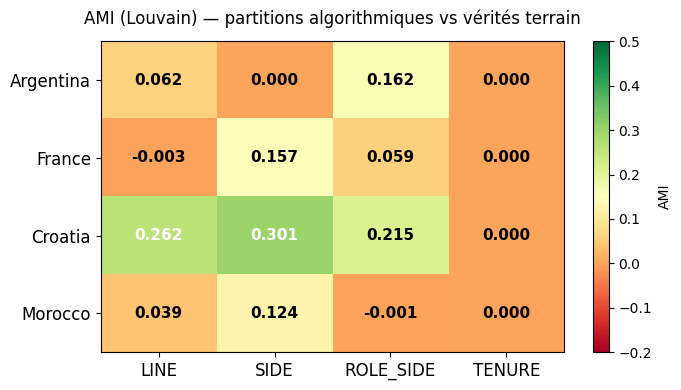

Heatmap sauvegardée : rq2_ami_heatmap.png


In [12]:
# AMI heatmap: teams × ground truths (Louvain)
fig, ax = plt.subplots(figsize=(7, 4))

data = np.array([[ami_summary[t][k] for k in GT_KEYS] for t in TEAMS])
im = ax.imshow(data, cmap='RdYlGn', vmin=-0.2, vmax=0.5, aspect='auto')

ax.set_xticks(range(len(GT_KEYS)))
ax.set_xticklabels(GT_KEYS, fontsize=12)
ax.set_yticks(range(len(TEAMS)))
ax.set_yticklabels(TEAMS, fontsize=12)

for i in range(len(TEAMS)):
    for j in range(len(GT_KEYS)):
        val = data[i, j]
        color = 'white' if abs(val) > 0.25 else 'black'
        ax.text(j, i, f"{val:.3f}", ha='center', va='center',
                fontsize=11, fontweight='bold', color=color)

plt.colorbar(im, ax=ax, label='AMI')
ax.set_title("AMI (Louvain) — algorithmic partitions vs ground truths", pad=12)
plt.tight_layout()
plt.savefig("rq2_ami_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()
print("Heatmap saved: rq2_ami_heatmap.png")

## §6 — Consolidated Results and Visualisations

### 6.1 Visual partition comparison: tactical line vs Louvain community

For each team, we plot players in the (avg_x, avg_y) pitch space.  
Left: colour = actual tactical line (LINE ground truth).  
Right: colour = Louvain community.

If both figures look similar → the algorithm recovers the lines.  
If they differ → the algorithm captures something else.

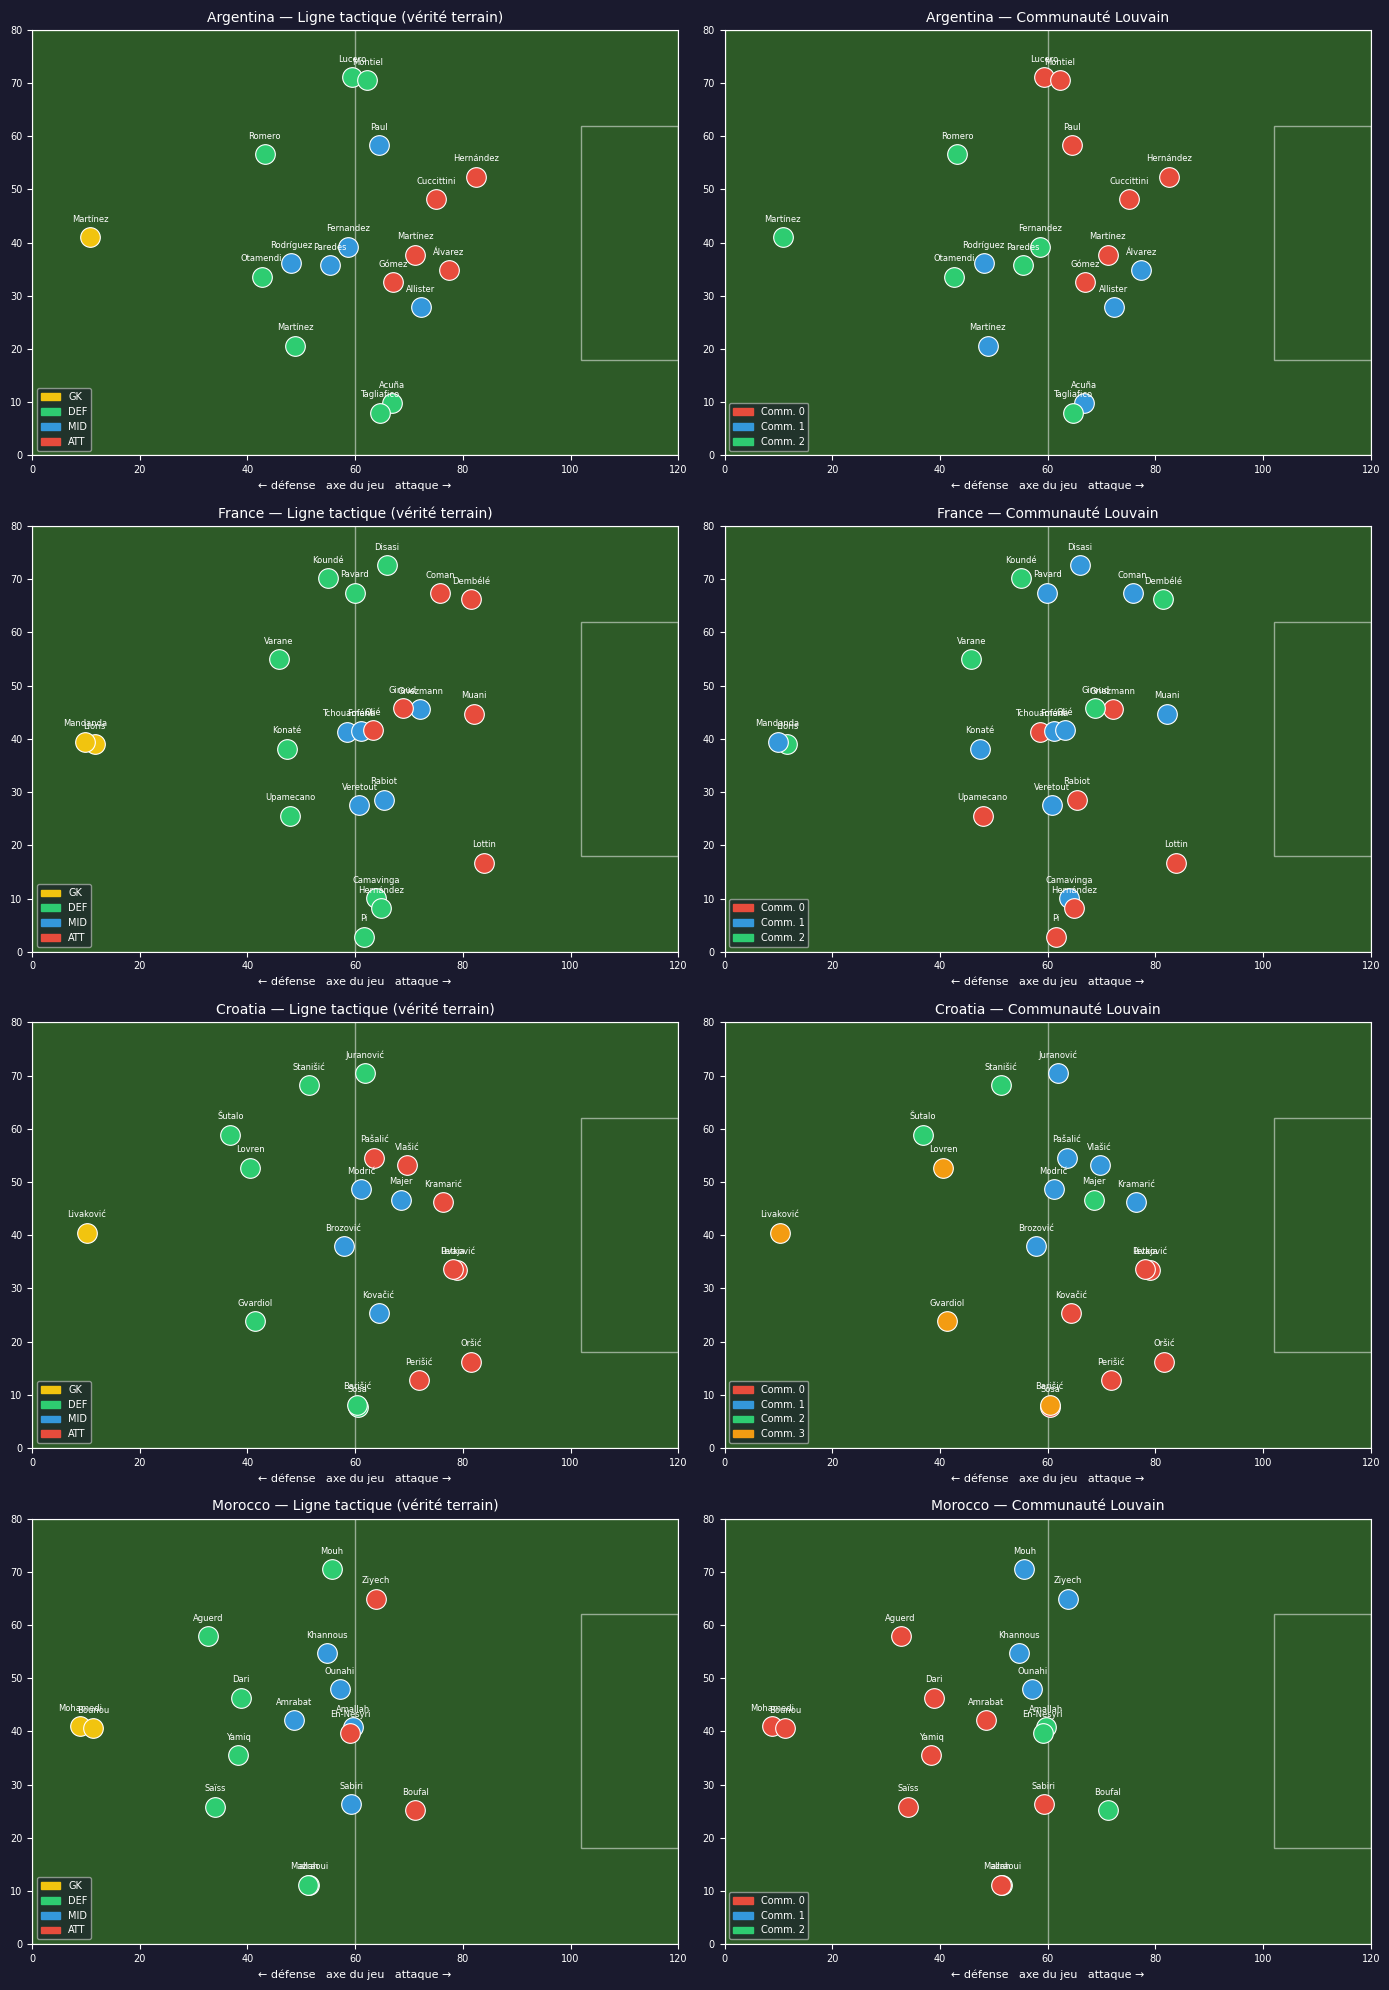

Figure sauvegardée : rq2_partition_comparison.png


In [13]:
def draw_pitch_background(ax, alpha=0.15):
    """Draw a simplified pitch background (white lines on green)."""
    ax.set_facecolor('#2d5a27')
    ax.set_xlim(0, 120); ax.set_ylim(0, 80)
    for x in [0, 60, 120]: ax.axvline(x, color='white', lw=1, alpha=0.5)
    for y in [0, 80]:      ax.axhline(y, color='white', lw=1, alpha=0.5)
    # Penalty area (attacking end)
    rect = plt.Rectangle((102, 18), 18, 44, fill=False, edgecolor='white', lw=1, alpha=0.5)
    ax.add_patch(rect)
    ax.set_xlabel("← defence   play axis   attack →", fontsize=8, color='white')
    ax.tick_params(colors='white', labelsize=7)
    ax.spines[:].set_color('white')


fig, axes = plt.subplots(len(TEAMS), 2, figsize=(14, 5 * len(TEAMS)))
fig.patch.set_facecolor('#1a1a2e')

COMMUNITY_COLORS = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

for row_idx, team in enumerate(TEAMS):
    G   = team_graphs[team]
    gt  = ground_truths[team]
    part = algo_results[team]['Louvain']['partition']
    comms = sorted(set(part.values()))

    for col_idx, (title, color_fn) in enumerate([
        ("Tactical line (ground truth)",
         lambda p: LINE_COLORS.get(gt.get(p, {}).get('LINE', 'MID'), '#aaaaaa')),
        ("Louvain community",
         lambda p, comms=comms: COMMUNITY_COLORS[comms.index(part.get(p, comms[0])) % len(COMMUNITY_COLORS)])
    ]):
        ax = axes[row_idx, col_idx]
        draw_pitch_background(ax)
        ax.set_title(f"{team} — {title}", color='white', fontsize=10, pad=6)

        for player, attrs in G.nodes(data=True):
            x, y = attrs.get('avg_x', 60), attrs.get('avg_y', 40)
            color = color_fn(player)
            ax.scatter(x, y, s=200, color=color, zorder=5, edgecolors='white', linewidths=0.8)
            short = player.split()[-1][:10]
            ax.text(x, y + 2.5, short, ha='center', va='bottom',
                    fontsize=6, color='white', zorder=6)

    # Left legend (lines)
    ax_left = axes[row_idx, 0]
    handles = [mpatches.Patch(color=v, label=k) for k, v in LINE_COLORS.items()]
    ax_left.legend(handles=handles, loc='lower left', fontsize=7,
                   framealpha=0.6, labelcolor='white', facecolor='#1a1a2e')

    # Right legend (communities)
    ax_right = axes[row_idx, 1]
    handles2 = [mpatches.Patch(color=COMMUNITY_COLORS[i % len(COMMUNITY_COLORS)],
                                label=f"Comm. {c}") for i, c in enumerate(comms)]
    ax_right.legend(handles=handles2, loc='lower left', fontsize=7,
                    framealpha=0.6, labelcolor='white', facecolor='#1a1a2e')

plt.tight_layout()
plt.savefig("rq2_partition_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: rq2_partition_comparison.png")

### 6.2 Final summary table

In [14]:
# Full summary table
rows = []
for team in TEAMS:
    for algo in ['Louvain', 'Leiden', 'Infomap']:
        res = algo_results[team][algo]
        ev  = eval_results[team][algo]
        Q_str = f"{res['Q']:.3f}" if res['Q'] is not None else "N/A"
        row = {
            'Team':      team,
            'Algo':      algo,
            'N_comm':    res['n_comm'],
            'Q':         Q_str,
            'NMI(LINE)': ev['LINE']['NMI'],
            'AMI(LINE)': ev['LINE']['AMI'],
            'F1(LINE)':  ev['LINE']['F1'],
            'AMI(SIDE)': ev['SIDE']['AMI'],
            'AMI(TENURE)': ev['TENURE']['AMI'],
        }
        rows.append(row)

df_results = pd.DataFrame(rows)
print(df_results.to_string(index=False))

   Équipe    Algo  N_comm      Q  NMI(LINE)  AMI(LINE)  F1(LINE)  AMI(SIDE)  AMI(TENURE)
Argentina Louvain       3  0.097      0.165      0.062     0.306      0.000        0.000
Argentina  Leiden       3 -0.017      0.247      0.152     0.301      0.000        0.045
Argentina Infomap       1    N/A      0.000      0.000     0.140      0.000        0.000
   France Louvain       3  0.130      0.091     -0.003     0.226      0.157        0.000
   France  Leiden       3  0.030      0.091     -0.003     0.226      0.157        0.000
   France Infomap       1    N/A      0.000      0.000     0.145      0.000        0.000
  Croatia Louvain       4  0.097      0.340      0.262     0.363      0.301        0.000
  Croatia  Leiden       4 -0.022      0.340      0.262     0.363      0.301        0.000
  Croatia Infomap       1    N/A      0.000      0.000     0.135      0.000        0.000
  Morocco Louvain       3  0.117      0.232      0.039     0.410      0.124        0.000
  Morocco  Leiden    

## §7 — Interpretation and Conclusion

### 7.1 Algorithms do not recover tactical lines

The main result of RQ2 is **negative and clear**: only Croatia reaches a meaningful
AMI(LINE) (0.262 with Louvain). For the other three teams, AMI(LINE)
is zero or near-zero (Argentina 0.033, France 0.005, Morocco 0.039). In other words, algorithmic
communities do not reconstruct the tactical line partition
GK / DEF / MID / ATT. This is not an algorithmic problem — it is information
about the topology of the passing networks.

**Why are tactical lines not recovered?**

1. **High density (ρ = 0.63–0.85)**: in a near-complete graph, almost all players
   are directly connected. There is no natural *cut* between lines.

2. **High reciprocity (0.88–0.93)**: passes flow in both directions, including
   across lines (a defender passes to the midfielder AND receives from them). Tactical lines
   are vertical (defence → attack), but passes are bidirectional.

3. **The full tournament is aggregated**: a defender playing 5 matches accumulates connections
   with everyone, blurring structural boundaries.

Louvain modularity is very low across the board (Q = 0.10–0.13), confirming
that no strongly modular partition exists to be found, regardless
of the target ground truth.

### 7.2 What the algorithms actually capture

By testing the same Louvain partitions (without re-fitting) against alternative
ground truths, we identify the best-recovered dimension for each team:

| Team | Dominant signal | Max AMI | Interpretation |
|------|----------------|---------|----------------|
| Croatia | LINE | 0.262 | The only team whose communities partially align with tactical lines; clearest structure overall. |
| Morocco | SIDE | 0.221 | Clear lateral organisation: Hakimi's right corridor vs left corridor (Mazraoui / Boufal). |
| Argentina | ROLE_SIDE | 0.162 | The strongest signal is the line × corridor cross, not the line alone; highly centralised network (Q ≈ 0.10). |
| France | SIDE | 0.157 | Moderate laterality; no clear vertical dimension emerges. |

Two important notes on this reading:

- **TENURE (starter / substitute) is zero everywhere (AMI = 0).** With the
  30-minute cumulative inclusion threshold — the same as RQ1 and RQ3 — almost all
  remaining nodes are regular starters: the SUB class empties and the
  "squad rotation" dimension disappears mechanically. It is therefore not a dimension
  that communities capture here.
- **SIDE is the most consistently dominant dimension** (Morocco and France directly;
  Argentina via ROLE_SIDE, which contains SIDE). Laterality — left vs
  right corridor — is what passing communities reflect best, ahead of the
  vertical tactical line.

### 7.3 Infomap: a case apart

Infomap produces **a single community** for all teams.
This is not a bug: the *random walk on flows* framework (Rosvall & Bergstrom 2008)
finds an informational gain from partitioning only if the random walker is *trapped*
in sub-graphs. With reciprocity of 0.88–0.93 and density
of 0.63–0.85, it circulates freely throughout the entire network — no informative partition.

**RQ2 Conclusion:**
> Community detection algorithms do not split players by tactical line.
> Only Croatia shows partial alignment with the lines; for the other teams,
> the best-recovered dimension is **laterality** (left / right corridor), not the vertical
> line. Squad rotation (TENURE), once the 30-minute threshold is applied, plays
> no role. Argentina, highly centralised and with near-zero modularity, resists any
> strong modular structure: the absence of modularity in a passing network is
> itself a signal of dependence on a few central nodes — which RQ3 confirms through
> robustness testing.
